### Student Performance Indicator

#### > Life cycle of Machine learning Project


-  Understanding the Problem Statement

- Data Collection

- Data Checks to perform

- Exploratory data analysis

- Data Pre-Processing

- Model Training

- Choose best model

1) Problem statement


- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
The data consists of 8 column and 1000 rows.

2.1 Import Data and Required Packages


Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [4]:
df = pd.read_csv('raw.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1001, 8)

## 2.2 Dataset information

- **gender** : sex of students -> (Male/female)

- **race/ethnicity** : ethnicity of students -> (Group A, B, C, D, E)

- **parental level of education** : parents' final education ->  
  (bachelor's degree, some college, master's degree, associate's degree, high school)

- **lunch** : having lunch before test (standard or free/reduced)

- **test preparation course** : complete or not complete before test

- **math score**

- **reading score**

- **writing score**


# 3. Data Checks to perform

- Check Missing values

- Check Duplicates

- Check data type

- Check the number of unique values of each column

- Check statistics of data set

- Check various categories present in the different categorical column


## 3.1 Check Missing values

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in dataset.

### 3.3 Check datatypes

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1001 non-null   str  
 1   race/ethnicity               1001 non-null   str  
 2   parental level of education  1001 non-null   str  
 3   lunch                        1001 non-null   str  
 4   test preparation course      1001 non-null   str  
 5   math score                   1001 non-null   int64
 6   reading score                1001 non-null   int64
 7   writing score                1001 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.7 KB


In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [12]:
df.describe()

,math score,reading score,writing score
count,1001.000000,1001.000000,1001.000000
mean,66.110889,69.198801,68.080919
std,15.171311,14.623318,15.211918
min,0.000000,17.000000,10.000000
25%,57.000000,59.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


Insight


- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

##### 3.7 Exploring Data

In [25]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [36]:
# Step 1: Check duplicates
print("=== DUPLICATE CHECK ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Step 2: Investigate zero scores
print("\n=== ZERO/LOW SCORE INVESTIGATION ===")
print(f"Math score = 0 : {(df['math score']==0).sum()} students")
print(f"Math score < 10: {(df['math score']<10).sum()} students")

# Step 3: Create your target variable
df['average_score'] = (df['math score'] +
                       df['reading score'] +
                       df['writing score']) / 3

print("\n=== TARGET VARIABLE (average_score) ===")
print(df['average_score'].describe().round(2))

=== DUPLICATE CHECK ===
Duplicate rows: 1

=== ZERO/LOW SCORE INVESTIGATION ===
Math score = 0 : 1 students
Math score < 10: 2 students

=== TARGET VARIABLE (average_score) ===
count    1001.00
mean       67.80
std        14.27
min         9.00
25%        58.33
50%        68.33
75%        77.67
max       100.00
Name: average_score, dtype: float64


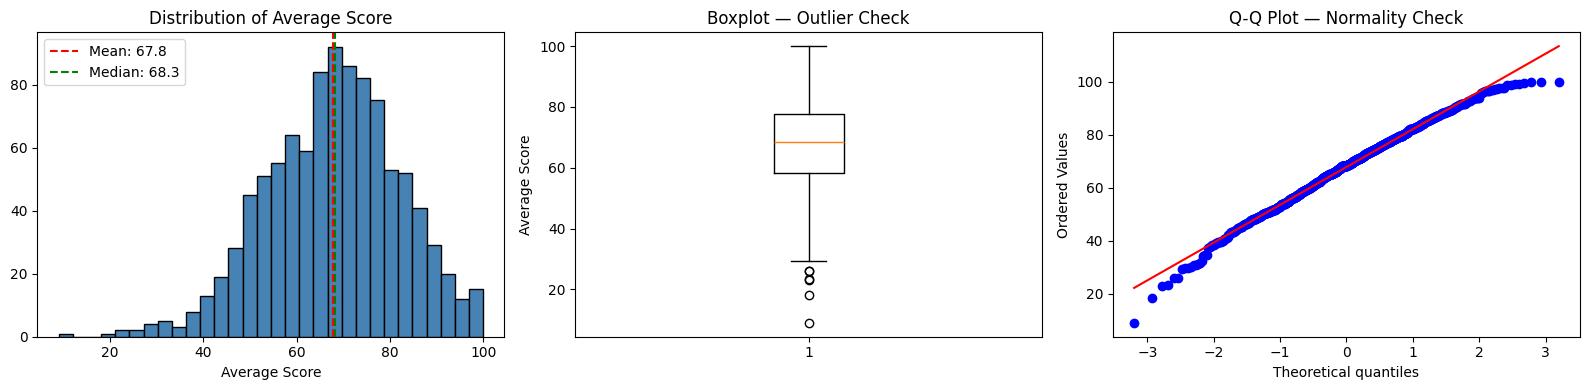


Shapiro-Wilk Test → p-value: 0.0002
Distribution is: NOT NORMAL ⚠️


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Histogram
axes[0].hist(df['average_score'], bins=30,
             color='steelblue', edgecolor='black')
axes[0].axvline(df['average_score'].mean(),
                color='red', linestyle='--', label=f"Mean: {df['average_score'].mean():.1f}")
axes[0].axvline(df['average_score'].median(),
                color='green', linestyle='--', label=f"Median: {df['average_score'].median():.1f}")
axes[0].set_title('Distribution of Average Score')
axes[0].set_xlabel('Average Score')
axes[0].legend()

# Plot 2: Boxplot
axes[1].boxplot(df['average_score'], vert=True)
axes[1].set_title('Boxplot — Outlier Check')
axes[1].set_ylabel('Average Score')

# Plot 3: Q-Q Plot (Normality)
stats.probplot(df['average_score'], plot=axes[2])
axes[2].set_title('Q-Q Plot — Normality Check')

plt.tight_layout()
plt.show()

# Shapiro-Wilk Test
stat, p = stats.shapiro(df['average_score'].sample(500, random_state=42))
print(f"\nShapiro-Wilk Test → p-value: {p:.4f}")
print(f"Distribution is: {'NORMAL ✅' if p > 0.05 else 'NOT NORMAL ⚠️'}")

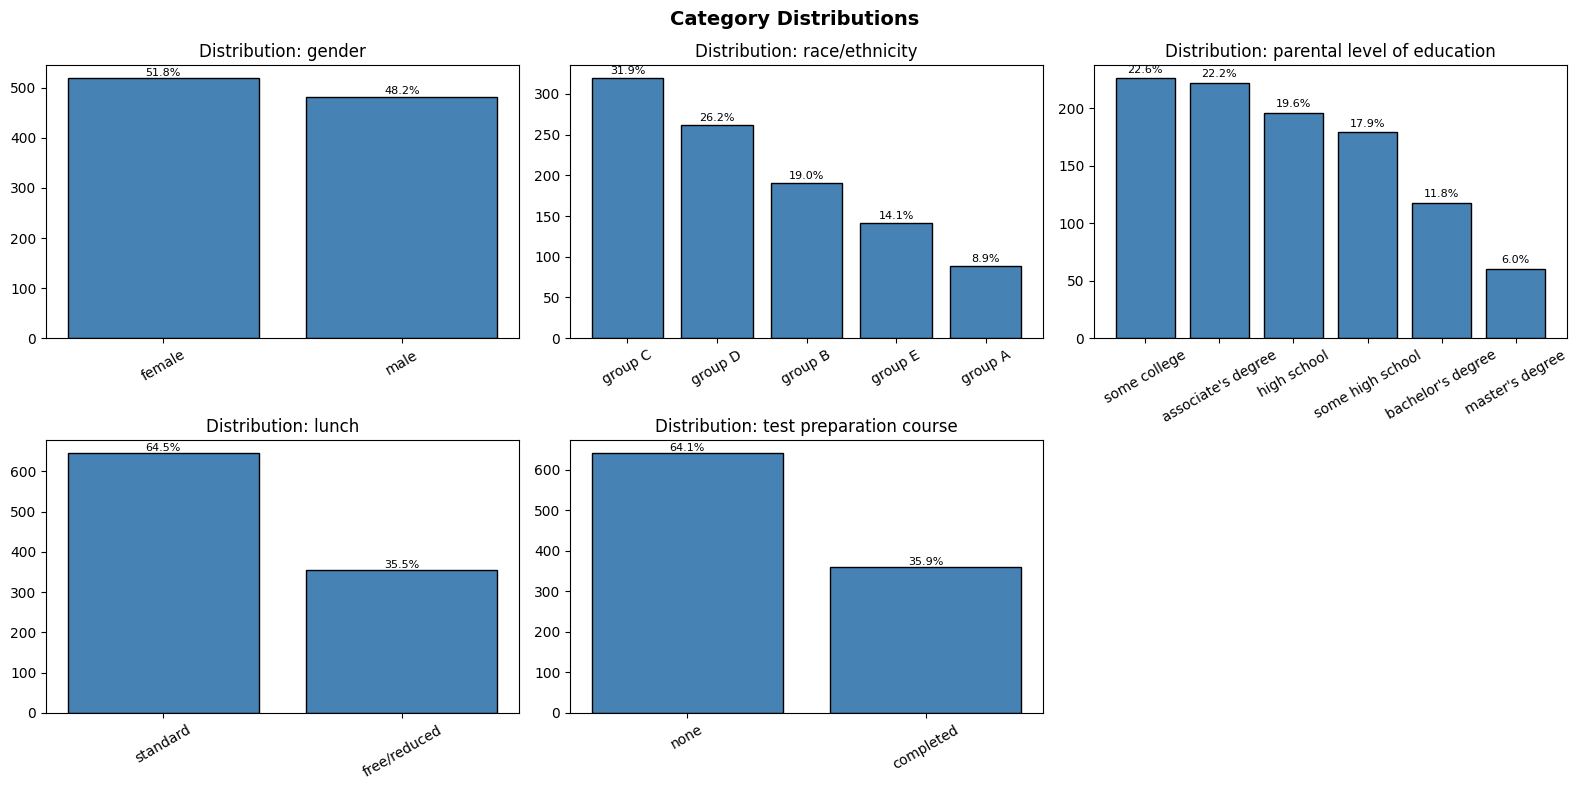

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cat_features = ['gender', 'race/ethnicity',
                'parental level of education',
                'lunch', 'test preparation course']

for idx, col in enumerate(cat_features):
    row, col_idx = divmod(idx, 3)
    counts = df[col].value_counts()
    axes[row][col_idx].bar(counts.index, counts.values,
                           color='steelblue', edgecolor='black')
    axes[row][col_idx].set_title(f'Distribution: {col}')
    axes[row][col_idx].tick_params(axis='x', rotation=30)
    # Add percentage labels
    total = len(df)
    for i, v in enumerate(counts.values):
        axes[row][col_idx].text(i, v + 5, f'{v/total*100:.1f}%',
                                ha='center', fontsize=8)

# Hide empty subplot
axes[1][2].set_visible(False)
plt.suptitle('Category Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

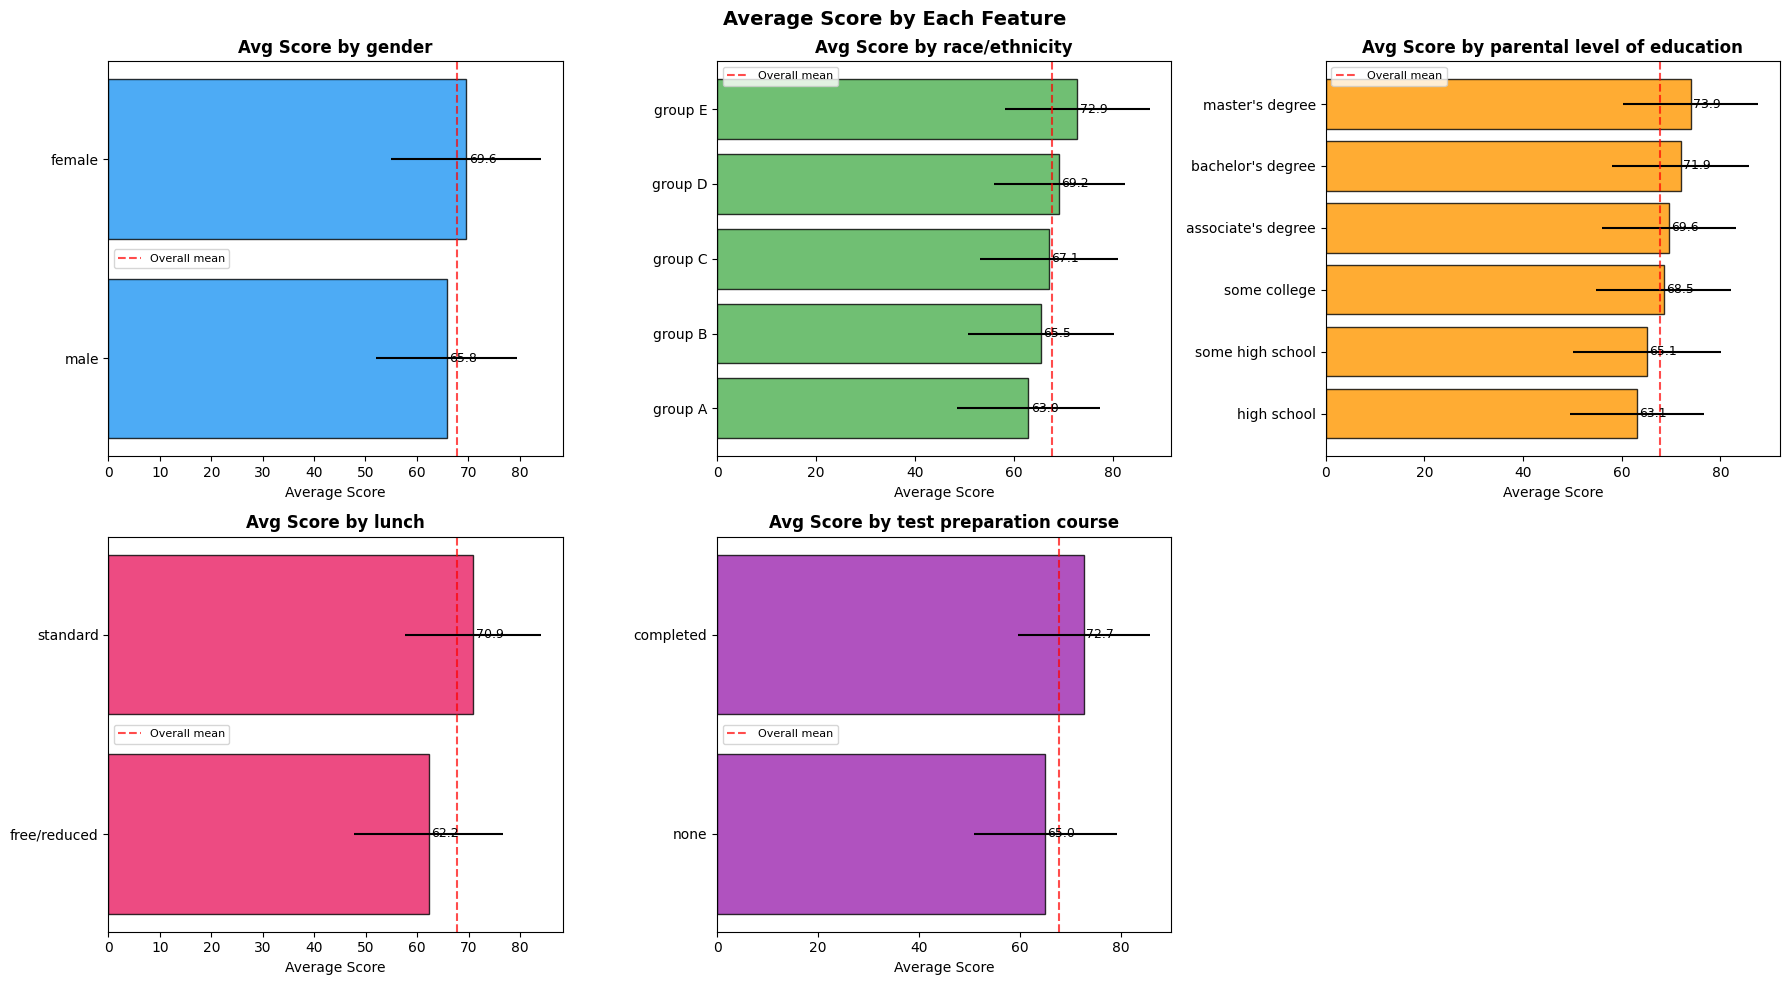

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_features = ['gender', 'race/ethnicity',
                'parental level of education',
                'lunch', 'test preparation course']

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for idx, feature in enumerate(cat_features):
    row, col_idx = divmod(idx, 3)
    
    # Group means
    group_means = df.groupby(feature)['average_score'].mean().sort_values()
    group_std = df.groupby(feature)['average_score'].std()
    
    axes[row][col_idx].barh(group_means.index,
                             group_means.values,
                             xerr=group_std[group_means.index],
                             color=colors[idx], alpha=0.8,
                             edgecolor='black')
    axes[row][col_idx].set_title(f'Avg Score by {feature}',
                                  fontweight='bold')
    axes[row][col_idx].set_xlabel('Average Score')
    axes[row][col_idx].axvline(df['average_score'].mean(),
                                color='red', linestyle='--',
                                alpha=0.7, label='Overall mean')
    axes[row][col_idx].legend(fontsize=8)
    
    # Add mean values on bars
    for i, (val, name) in enumerate(zip(group_means.values,
                                         group_means.index)):
        axes[row][col_idx].text(val + 0.5, i,
                                 f'{val:.1f}', va='center', fontsize=9)

axes[1][2].set_visible(False)
plt.suptitle('Average Score by Each Feature',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
print("=" * 55)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 55)
print("Question: Is the score difference REAL or just random?")
print("Rule: p < 0.05 → difference is statistically significant")
print("=" * 55)

# 1. Gender (T-test — 2 groups)
male = df[df['gender']=='male']['average_score']
female = df[df['gender']=='female']['average_score']
t, p = stats.ttest_ind(male, female)
print(f"\n1. GENDER")
print(f"   Male mean: {male.mean():.2f} | Female mean: {female.mean():.2f}")
print(f"   T-test → p={p:.4f} {'✅ SIGNIFICANT' if p<0.05 else '❌ NOT SIGNIFICANT'}")

# 2. Lunch (T-test — 2 groups)
std = df[df['lunch']=='standard']['average_score']
fr = df[df['lunch']=='free/reduced']['average_score']
t, p = stats.ttest_ind(std, fr)
print(f"\n2. LUNCH TYPE")
print(f"   Standard mean: {std.mean():.2f} | Free/reduced mean: {fr.mean():.2f}")
print(f"   T-test → p={p:.4f} {'✅ SIGNIFICANT' if p<0.05 else '❌ NOT SIGNIFICANT'}")

# 3. Test Prep (T-test — 2 groups)
comp = df[df['test preparation course']=='completed']['average_score']
none = df[df['test preparation course']=='none']['average_score']
t, p = stats.ttest_ind(comp, none)
print(f"\n3. TEST PREPARATION")
print(f"   Completed mean: {comp.mean():.2f} | None mean: {none.mean():.2f}")
print(f"   T-test → p={p:.4f} {'✅ SIGNIFICANT' if p<0.05 else '❌ NOT SIGNIFICANT'}")

# 4. Parental Education (ANOVA — 6 groups)
groups = [g['average_score'].values for _,g in
          df.groupby('parental level of education')]
f, p = stats.f_oneway(*groups)
print(f"\n4. PARENTAL EDUCATION")
print(f"   ANOVA → F={f:.2f}, p={p:.4f} {'✅ SIGNIFICANT' if p<0.05 else '❌ NOT SIGNIFICANT'}")

# 5. Race/Ethnicity (ANOVA — 5 groups)
groups = [g['average_score'].values for _,g in
          df.groupby('race/ethnicity')]
f, p = stats.f_oneway(*groups)
print(f"\n5. RACE/ETHNICITY")
print(f"   ANOVA → F={f:.2f}, p={p:.4f} {'✅ SIGNIFICANT' if p<0.05 else '❌ NOT SIGNIFICANT'}")

STATISTICAL SIGNIFICANCE TESTS
Question: Is the score difference REAL or just random?
Rule: p < 0.05 → difference is statistically significant

1. GENDER
   Male mean: 65.84 | Female mean: 69.62
   T-test → p=0.0000 ✅ SIGNIFICANT

2. LUNCH TYPE
   Standard mean: 70.87 | Free/reduced mean: 62.20
   T-test → p=0.0000 ✅ SIGNIFICANT

3. TEST PREPARATION
   Completed mean: 72.73 | None mean: 65.04
   T-test → p=0.0000 ✅ SIGNIFICANT

4. PARENTAL EDUCATION
   ANOVA → F=11.03, p=0.0000 ✅ SIGNIFICANT

5. RACE/ETHNICITY
   ANOVA → F=9.39, p=0.0000 ✅ SIGNIFICANT


In [42]:
# Find and remove it before ANY modeling
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after removing duplicate: {df.shape}")


Dataset shape after removing duplicate: (1000, 9)


In [43]:
# Investigate the outlier students
outlier_threshold = df['average_score'].quantile(0.01)
print("Bottom 1% students:")
print(df[df['average_score'] < outlier_threshold])

Bottom 1% students:
     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
76     male        group E            some high school      standard   
211    male        group C                some college  free/reduced   
327    male        group A                some college  free/reduced   
338  female        group B            some high school  free/reduced   
596    male        group B                 high school  free/reduced   
601  female        group C                 high school      standard   
787  female        group B                some college      standard   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  \
17                     none          18             32             28   
59                     none           0  

In [44]:
# Calculate Effect Size (Cohen's d) for binary features
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return abs(diff / pooled_std)

# Lunch effect size
d_lunch = cohens_d(
    df[df['lunch']=='standard']['average_score'],
    df[df['lunch']=='free/reduced']['average_score']
)

# Test prep effect size
d_prep = cohens_d(
    df[df['test preparation course']=='completed']['average_score'],
    df[df['test preparation course']=='none']['average_score']
)

# Gender effect size
d_gender = cohens_d(
    df[df['gender']=='female']['average_score'],
    df[df['gender']=='male']['average_score']
)

print(f"Cohen's d — Lunch:     {d_lunch:.3f}")
print(f"Cohen's d — Test Prep: {d_prep:.3f}")
print(f"Cohen's d — Gender:    {d_gender:.3f}")

# Interpretation:
# d < 0.2  → Small effect
# d = 0.5  → Medium effect
# d > 0.8  → Large effect

Cohen's d — Lunch:     0.624
Cohen's d — Test Prep: 0.560
Cohen's d — Gender:    0.264


✅ CONFIRMED FINDINGS:
────────────────────────────────────────────────────
1. Dataset has 1 duplicate → REMOVE before modeling
2. Target (avg score) ≈ normal, mild left tail → OK for regression
3. 3 low-score outliers → INVESTIGATE, probably keep
4. ALL 5 features are statistically significant → KEEP ALL
5. Lunch type = strongest socioeconomic signal
6. Test prep = most actionable intervention feature
7. Parental education = ORDINAL gradient (not nominal)
8. Gender gap is real but modest (3.8 points)
9. Race/ethnicity gap exists → fairness audit needed

⚠️ WARNINGS FOR MODELING:
────────────────────────────────────────────────────
1. Group A (race) and Master's (parental edu) are small
   → model may underperform on these subgroups
2. Parental education MUST be ordinally encoded
3. Dataset is likely synthetic → don't over-generalize

FEATURE RANKING FOR YOUR MODEL:

──────────────────────────────────────────────────────
Rank  Feature               Effect    Type
──────────────────────────────────────────────────────

 1    lunch                 0.624     Socioeconomic proxy

 2    test preparation      0.560     Intervention signal

 3    parental education    ~0.5*     Gradient effect (ANOVA)

 4    race/ethnicity        ~0.4*     Group variation (ANOVA)

 5    gender                0.264     Demographic gap

──────────────────────────────────────────────────────

* Estimated from ANOVA F-scores, not Cohen's d